# **Pokemon Speed Prediction Model**
**Goal:** predict speed of a pokemon using multiple featured linear regression.
**Columns:**
1. Num: Number of indexes ***(Unnecesarry)***
2. Name: Names of each pokemon ***(Unnecesarry)***
3. Type1: Type of pokemon ***(X Neccesarry)***
4. Type2: Type of pokemon ***(X Neccesarry)***
5. HP: Health Point of the pokemon (shows tankyness of the pokemon, ***(X Neccesarry)***
6. Attack: Base attack damage of the pokemon ***(X Neccesarry)***
7. Defense: Base defence of the pokemon ***(X Neccesarry)***
8. SPAtk: Special attack damage of the pokemon ***(X Neccesarry)***
9. SPDef: Special defence of the pokemon ***(X Neccesarry)***
10. Speed: Our target variable ***(y Neccesarry)***
11. Generation: Shows which generation pokemon was created. ***(Unnecesarry)***
12. Legendary: ***(X Neccesarry)***



In [62]:
import pandas as pd
import numpy as np

path = "/content/PokemonData.csv"
poke = pd.read_csv(path)
poke

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True


# **DATA PREPROCESSING**
1) get rid of unnecesarry features (columns).

In [ ]:
#DROP: Num, Name, Generation
poke = poke.drop(columns=['Num', 'Name','Generation'])

In [71]:
# turn col:legendary from true/false to 1/0 by mapping each one.
poke['Legendary'] = poke['Legendary'].astype(int)
poke

,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Legendary
0,Grass,Poison,45,49,49,65,65,45,0
1,Grass,Poison,60,62,63,80,80,60,0
2,Grass,Poison,80,82,83,100,100,80,0
3,Grass,Poison,80,100,123,122,120,80,0
4,Fire,NaN,39,52,43,60,50,65,0
...,...,...,...,...,...,...,...,...,...
795,Rock,Fairy,50,100,150,100,150,50,1
796,Rock,Fairy,50,160,110,160,110,110,1
797,Psychic,Ghost,80,110,60,150,130,70,1
798,Psychic,Dark,80,160,60,170,130,80,1


In [73]:
# Inspect:
poke.info() #type2 has a lot of NaN values. Handle them
poke['Type2'] = poke['Type2'].fillna('None') #chagned NaN to None.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Type1      800 non-null    object
 1   Type2      800 non-null    object
 2   HP         800 non-null    int64 
 3   Attack     800 non-null    int64 
 4   Defense    800 non-null    int64 
 5   SpAtk      800 non-null    int64 
 6   SpDef      800 non-null    int64 
 7   Speed      800 non-null    int64 
 8   Legendary  800 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 56.4+ KB


,Type2
0,Poison
1,Poison
2,Poison
3,Poison
4,None
...,...
795,Fairy
796,Fairy
797,Ghost
798,Dark


In [77]:
#handling type1 and type2

#type1 and type2 are string values which linear regression models dont understand. To fix this:
#One Hot Encoding: A method that changes word or text labels into numbers.
#We will make a new column for each type1 and type2.

# drop_first=True important to cure multicollinearity ***
# dtype=int turns tue false to 1 0.
poke_encoded = pd.get_dummies(poke, columns=['Type1', 'Type2'], drop_first=True, dtype=int)
#created new column for each type that has binary value.
poke_encoded

,HP,Attack,Defense,SpAtk,SpDef,Speed,Legendary,Type1_Dark,Type1_Dragon,Type1_Electric,...,Type2_Grass,Type2_Ground,Type2_Ice,Type2_None,Type2_Normal,Type2_Poison,Type2_Psychic,Type2_Rock,Type2_Steel,Type2_Water
0,45,49,49,65,65,45,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,60,62,63,80,80,60,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,80,82,83,100,100,80,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,80,100,123,122,120,80,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,39,52,43,60,50,65,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,50,100,150,100,150,50,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
796,50,160,110,160,110,110,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
797,80,110,60,150,130,70,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
798,80,160,60,170,130,80,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
#train test split:
#we must specify independent and dependent variables:
# y = dependent = Speed
# X = independent = everything except "Speed"
y = poke_encoded['Speed'] # Hata buradaydı: Köşeli parantez ile düzeltildi
X = poke_encoded.drop(columns=['Speed'])
print("created X and y dataframes.  ")
#now we split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 19)
#splits X and y to two parts
print(f"splitting done\nX_train shape:{X_train.shape}\nX_test shape: {X_test.shape}\ny_train shape: {y_train.shape}\ny_test shape: {y_test.shape}")

created X and y dataframes.  
splitting done
X_train shape:(640, 41)
X_test shape: (160, 41)
y_train shape: (640,)
y_test shape: (160,)


In [86]:
#FEATURE SCALING:
#poke_encoded.describe()
# Not all features are not too similar with each other. So we must scale them to protect the model accuracy.
# for example HP(min=1, max=255), Atk(min=5, max=190), Defense(min=10, max=230)
# the difference may not seem too much but scaling is always okay to have in preprocessing.
# for scaling, we will use sklearn StandardScaler.

from sklearn.preprocessing import StandardScaler
#Only X_train and X_test will be scaled.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fitted and transformed according to scaler algorithm
X_test_scaled = scaler.transform(X_test) #transformed according to scaler algorithm.
print("scaling done.")

scaling done.


In [89]:
#Now that all our datasets are ready, we can create the model and make predictions.
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled,y_train) #label and inputs are given. Model will train using these.
print("model completed")
y_pred = lr.predict(X_test_scaled) #create prediction using X_test_scaled. Later will be used for y_test - y_pred
print("created prediction for X_test_scaled")

model completed
created prediction for X_test_scaled


In [92]:
#Now we can test our success:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Ortlama Kare Hata   : {mse:.4f}")
print(f"Ortalama Mutlak Hata (MAE)     : {mae:.4f}")
print(f"Kök Ortalama Kare Hata (RMSE)  : {rmse:.4f}")
print(f"R-Kare (R2 Score)             : {r2:.4f}")

Ortlama Kare Hata   : 599.4386
Ortalama Mutlak Hata (MAE)     : 19.2083
Kök Ortalama Kare Hata (RMSE)  : 24.4834
R-Kare (R2 Score)             : 0.3503


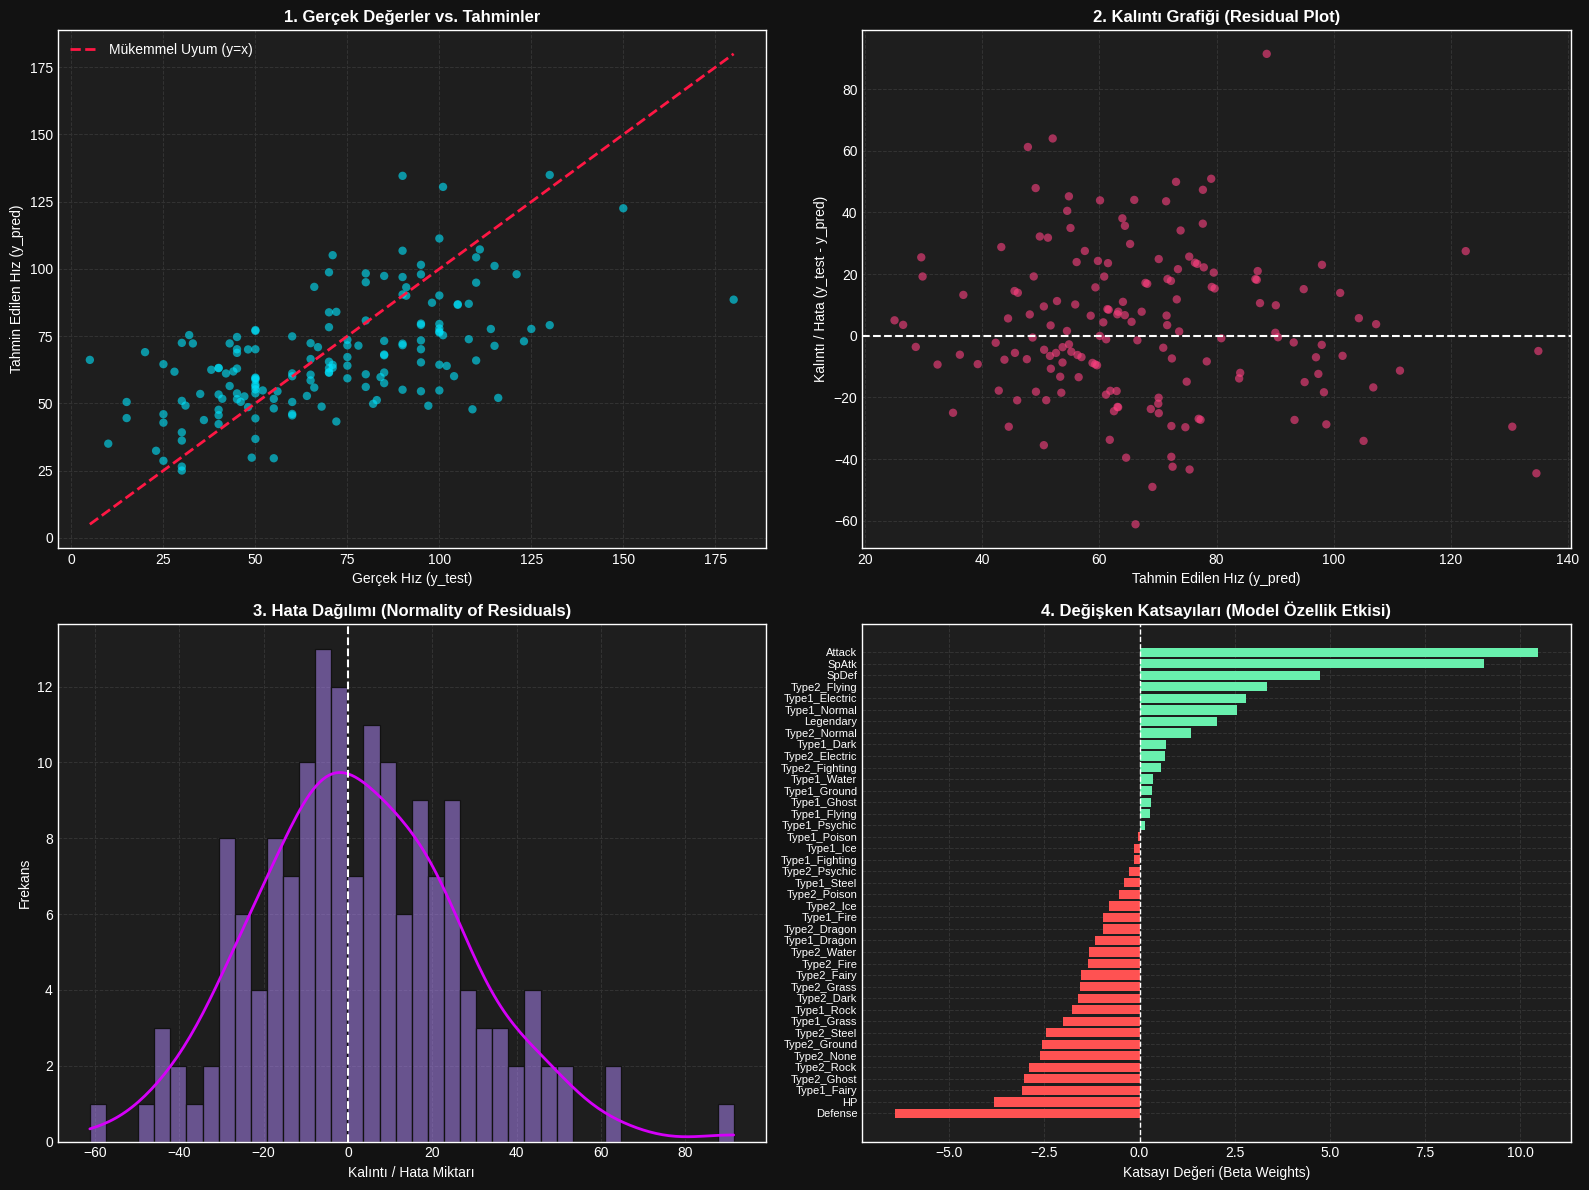

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------------------------------------------------
# Karanlık Mod Tema Ayarları
# -------------------------------------------------------------------------
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#121212') # Figür arka planı (Koyu Gri)

for ax in axes.flat:
    ax.set_facecolor('#1e1e1e')   # Grafik iç alan arka planı
    ax.grid(color='#333333', linestyle='--', linewidth=0.7) # Grid çizgileri

# Kalıntıları (Residuals) Hesaplama
kalintilar = y_test - y_pred

# -------------------------------------------------------------------------
# 1. Gerçek Değerler vs. Tahmin Edilen Değerler (Actual vs. Predicted)
# -------------------------------------------------------------------------
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, ax=axes[0, 0], color="#00e5ff", edgecolor="none")

# Mükemmel tahmin doğrusu (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], color="#ff1744", linestyle="--", lw=2, label="Mükemmel Uyum (y=x)")

axes[0, 0].set_title("1. Gerçek Değerler vs. Tahminler", fontsize=12, fontweight="bold", color="white")
axes[0, 0].set_xlabel("Gerçek Hız (y_test)", color="white")
axes[0, 0].set_ylabel("Tahmin Edilen Hız (y_pred)", color="white")
axes[0, 0].legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

# -------------------------------------------------------------------------
# 2. Kalıntı Grafiği (Residual Plot - Homoscedasticity Kontrolü)
# -------------------------------------------------------------------------
sns.scatterplot(x=y_pred, y=kalintilar, alpha=0.6, ax=axes[0, 1], color="#ff4081", edgecolor="none")
axes[0, 1].axhline(y=0, color="white", linestyle="--", lw=1.5)

axes[0, 1].set_title("2. Kalıntı Grafiği (Residual Plot)", fontsize=12, fontweight="bold", color="white")
axes[0, 1].set_xlabel("Tahmin Edilen Hız (y_pred)", color="white")
axes[0, 1].set_ylabel("Kalıntı / Hata (y_test - y_pred)", color="white")

# -------------------------------------------------------------------------
# 3. Kalıntıların Dağılımı (Normallik Varsayımı Kontrolü)
# -------------------------------------------------------------------------
sns.histplot(kalintilar, kde=True, ax=axes[1, 0], color="#b388ff", bins=40, edgecolor="#121212")
axes[1, 0].axvline(x=0, color="white", linestyle="--", lw=1.5)

# KDE çizgi rengini belirginleştirme
axes[1, 0].lines[0].set_color('#d500f9')
axes[1, 0].lines[0].set_linewidth(2)

axes[1, 0].set_title("3. Hata Dağılımı (Normality of Residuals)", fontsize=12, fontweight="bold", color="white")
axes[1, 0].set_xlabel("Kalıntı / Hata Miktarı", color="white")
axes[1, 0].set_ylabel("Frekans", color="white")

# -------------------------------------------------------------------------
# 4. Model Katsayıları / Özellik Önem Dereceleri (Feature Importance)
# -------------------------------------------------------------------------
# Standartlaştırma (Scaling) işlemi Pandas DataFrame'i Numpy Array'e çevirmiş olabilir.
# Sütun isimlerini güvenli bir şekilde almak için kontrol yapıyoruz:
features = X_train_scaled.columns if hasattr(X_train_scaled, 'columns') else X_train.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=True)

# Neon Kırmızı / Neon Yeşil renkler
colors = ["#ff5252" if c < 0 else "#69f0ae" for c in coef_df["Coefficient"]]
axes[1, 1].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="none")
axes[1, 1].axvline(x=0, color="white", linestyle="--", lw=1)

axes[1, 1].set_title("4. Değişken Katsayıları (Model Özellik Etkisi)", fontsize=12, fontweight="bold", color="white")
axes[1, 1].set_xlabel("Katsayı Değeri (Beta Weights)", color="white")
axes[1, 1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()